# Assignment 1 data import

This code imports the image data set used for the assignment. It also imports some of the standard libraries that you are likely to need and plots a couple of examples of the image data.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Torch version:', torch.__version__)


Using device: cpu
Torch version: 2.10.0


Below we load in the data from elab - I've also included a command below (commented out) to load in a local version in case you wish to work on a local machine. 

In [2]:
data = np.load('./Assignment1Data.npz')

In [3]:
data.files

['train_images', 'train_labels', 'test_images', 'test_labels']

Once the data have been loaded, assign each of the training, validation and test sets to their own array

In [4]:
train_data = data['train_images']
train_labels = data['train_labels'].ravel()
test_data = data['test_images']
test_labels = data['test_labels'].ravel()

In [5]:
label_dict = {
            0: "adipose",
            1: "lymphocytes",
            2: "normal colon mucosa",
            3: "cancer-associated stroma",
            4: "colorectal adenocarcinoma epithelium"
        }

In [6]:
# Shorter names for plot axis labels
class_names = ['Adipose', 'Lymphocytes', 'Normal Mucosa', 'Stroma', 'Cancer Epithelium']

In [7]:
# Dataset overview
print(f'Training images: {train_data.shape}')
print(f'Training labels: {train_labels.shape}')
print(f'Test images: {test_data.shape}')
print(f'Test labels: {test_labels.shape}')
print(f'Pixel value range: {train_data.min()} - {train_data.max()}')
print(f'Number of classes: {len(np.unique(train_labels))}')

print('\nClass distribution (training set):')
for i, name in enumerate(class_names):
    count = np.sum(train_labels == i)
    print(f'  Class {i} ({name}): {count} samples ({count/len(train_labels)*100:.1f}%)')

Training images: (55490, 28, 28, 3)
Training labels: (55490,)
Test images: (4367, 28, 28, 3)
Test labels: (4367,)
Pixel value range: 0 - 254
Number of classes: 5

Class distribution (training set):
  Class 0 (Adipose): 10407 samples (18.8%)
  Class 1 (Lymphocytes): 11557 samples (20.8%)
  Class 2 (Normal Mucosa): 8763 samples (15.8%)
  Class 3 (Stroma): 10446 samples (18.8%)
  Class 4 (Cancer Epithelium): 14317 samples (25.8%)


**View an example image and its label**
note that each image is of size 28x28x3. The 28 corresponds to the height and width of the image in pixels. There are 3 channels, corresponding to the amount of Red, Green, and Blue in each pixel. 

Text(0.5, 0.01, 'adipose')

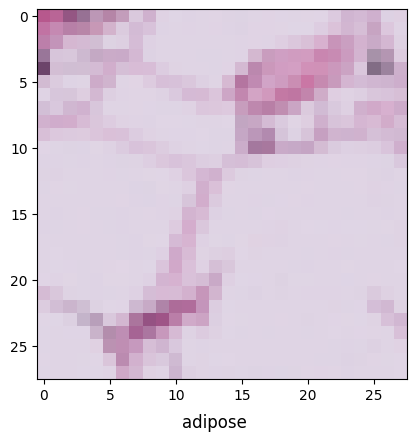

In [8]:
image1 = train_data[0,:,:,:]
plt.imshow(image1)
plt.figtext(0.5, 0.01, label_dict[train_labels[0]], wrap=True, horizontalalignment='center', fontsize=12)

We can look at each channel individually if we wish, by just plotting one of the layers:

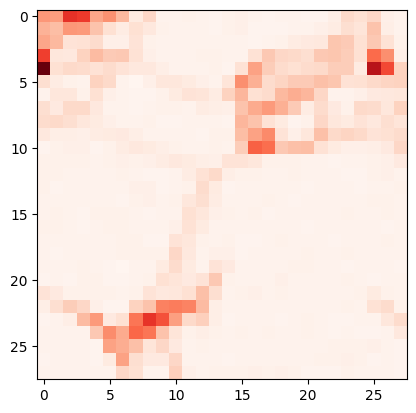

In [9]:
plt.imshow(train_data[0,:,:,0],cmap='Reds_r')

## Visualising Sample Images
Displaying five example images from each tissue class helps us visually inspect the differences and similarities between tissue types before training any model.

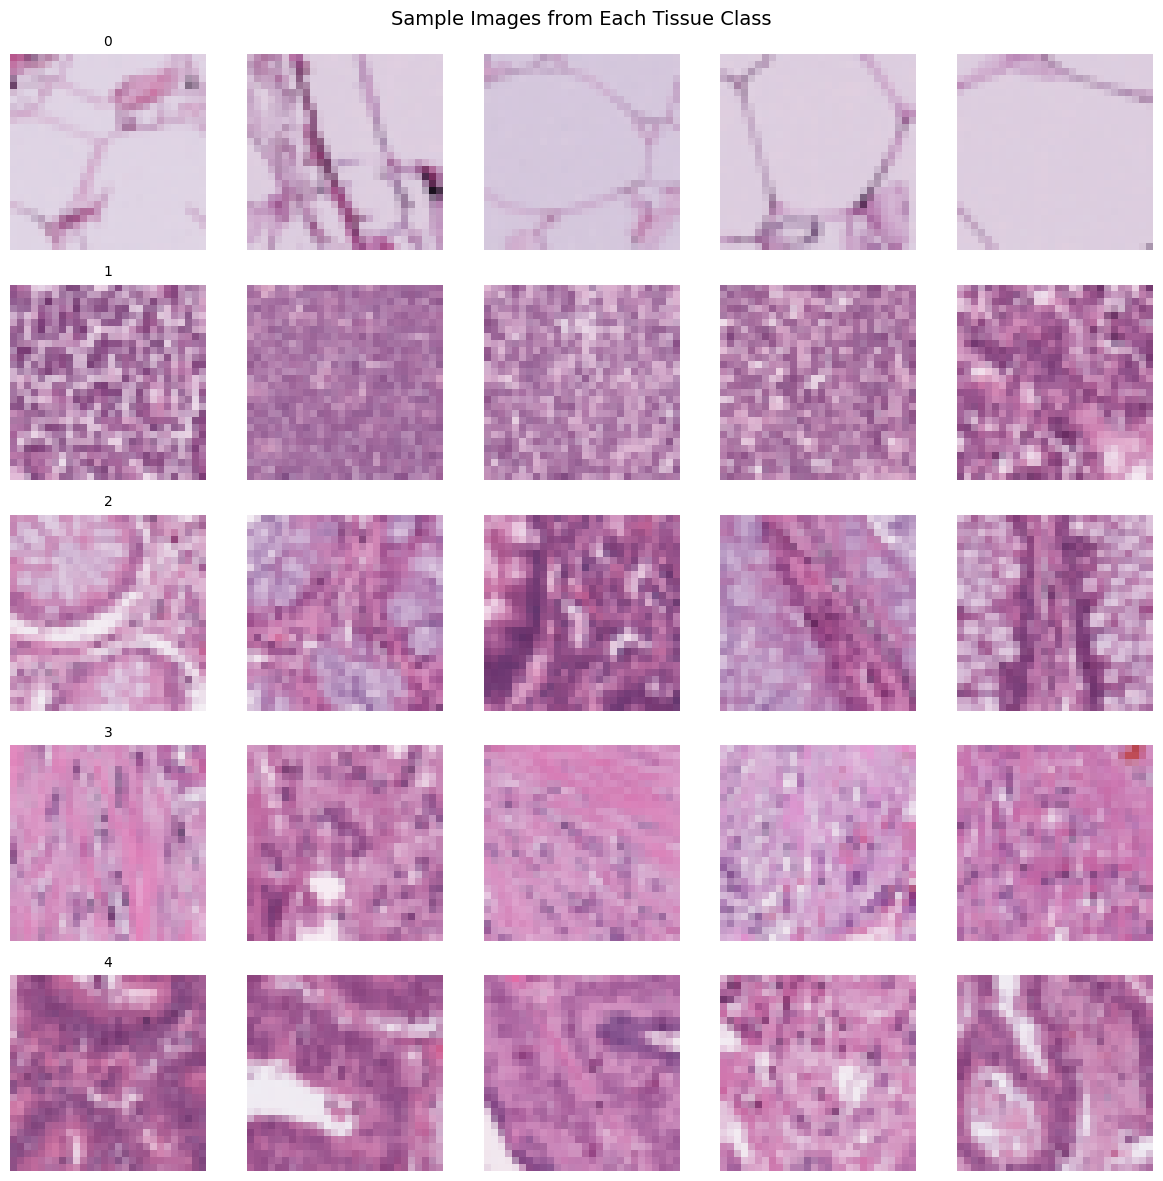

In [10]:
# Visualise sample images from each class

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, name in enumerate(label_dict):
    class_images = train_data[train_labels == i]
    for j in range(5):
        axes[i][j].imshow(class_images[j])
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(name, fontsize=10)
plt.suptitle('Sample Images from Each Tissue Class', fontsize=14)
plt.tight_layout()
plt.show()

## Class Distribution
Checking class distribution is important to identify any imbalance that could bias the model towards the majority class during training.

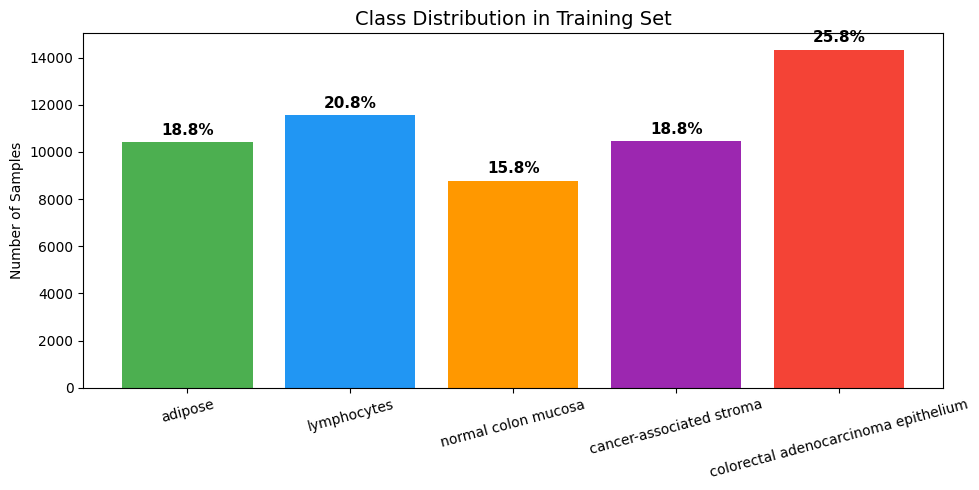

In [11]:
# Class Distribution in Training Set

fig, ax = plt.subplots(figsize=(10, 5))


counts = [np.sum(train_labels == i) for i in range(5)]
percentages = [count / len(train_labels) * 100 for count in counts]

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']
bars = ax.bar(list(label_dict.values()), counts, color=colors)

# Add percentage labels above each bar
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution in Training Set', fontsize=14)
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Train using SKlearn

The template provides a grayscale flattening approach. However, I will retain RGB channels because colour carries diagnostic information in H&E stained tissue. Eosin stains cytoplasm pink while haematoxylin stains nuclei blue. Discarding this information would remove a useful signal.

I also will flatten each 28×28×3 image into a 2,352-dimensional vector and normalise pixel values to [0, 1]. A stratified 80/20 train/validation split is created to monitor performance during development while keeping the test set completely untouched.

In [12]:
# Flatten images to 1D vectors, keeping all 3 RGB channels
X_train_flat = train_data.reshape(train_data.shape[0], -1)
X_test_flat = test_data.reshape(test_data.shape[0], -1)

# Normalise pixel values to [0, 1]
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set: {X_test_flat.shape[0]} samples')

Training set: 44392 samples
Validation set: 11098 samples
Test set: 4367 samples


Verifying that the stratified split preserved class proportions across training and validation sets.

In [13]:
print('\nClass proportions check:')
for i, name in enumerate(class_names):
    orig = np.sum(train_labels == i) / len(train_labels) * 100
    train_prop = np.sum(y_train == i) / len(y_train) * 100
    val_prop = np.sum(y_val == i) / len(y_val) * 100
    print(f'  {name}: Original {orig:.1f}%  Train {train_prop:.1f}%  Val {val_prop:.1f}%')


Class proportions check:
  Adipose: Original 18.8%  Train 18.8%  Val 18.8%
  Lymphocytes: Original 20.8%  Train 20.8%  Val 20.8%
  Normal Mucosa: Original 15.8%  Train 15.8%  Val 15.8%
  Stroma: Original 18.8%  Train 18.8%  Val 18.8%
  Cancer Epithelium: Original 25.8%  Train 25.8%  Val 25.8%


### Logistic Regression (Baseline)
A Logistic Regression classifier is trained as the baseline, using a StandardScaler pipeline for feature standardisation. We set max_iter=5000 to ensure convergence with 2,352 input features.

In [14]:

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

In [15]:
lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [16]:
y_val_pred_lr = lr.predict(X_val)

In [17]:
# classification_report and accuracy score
from sklearn.metrics import accuracy_score, classification_report

print('Logistic Regression Results (Validation Set):')
accuracy = accuracy_score(y_val, y_val_pred_lr) * 100
print(f" accuracy: {accuracy:.2f}%")

print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_lr, target_names= class_names))

Logistic Regression Results (Validation Set):
 accuracy: 70.51%

Classification Report:
                   precision    recall  f1-score   support

          Adipose       0.95      0.96      0.95      2081
      Lymphocytes       0.72      0.78      0.75      2311
    Normal Mucosa       0.46      0.32      0.38      1753
           Stroma       0.80      0.83      0.82      2089
Cancer Epithelium       0.56      0.60      0.58      2864

         accuracy                           0.71     11098
        macro avg       0.70      0.70      0.69     11098
     weighted avg       0.70      0.71      0.70     11098



### Random Forest (Additional Baseline)
A Random Forest with 100 trees is included to test whether a non-linear ensemble method 
improves on the linear baseline when using flattened image features.

In [18]:
# random forest.

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

In [19]:
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [20]:
y_val_pred_rf = rf.predict(X_val)

In [21]:
from sklearn.metrics import accuracy_score, classification_report


print(f"accuracy: {accuracy_score(y_val, y_val_pred_rf) * 100:.2f}%")

print(f"{classification_report(y_val, y_val_pred_rf, target_names=class_names)}")

accuracy: 77.19%
                   precision    recall  f1-score   support

          Adipose       0.95      0.99      0.97      2081
      Lymphocytes       0.84      0.82      0.83      2311
    Normal Mucosa       0.69      0.39      0.50      1753
           Stroma       0.77      0.82      0.79      2089
Cancer Epithelium       0.64      0.79      0.71      2864

         accuracy                           0.77     11098
        macro avg       0.78      0.76      0.76     11098
     weighted avg       0.77      0.77      0.76     11098



## Confusion Matrices for Sklearn Models
Confusion matrices show exactly where each model makes mistakes — which classes get confused with which. This is more informative than accuracy alone.

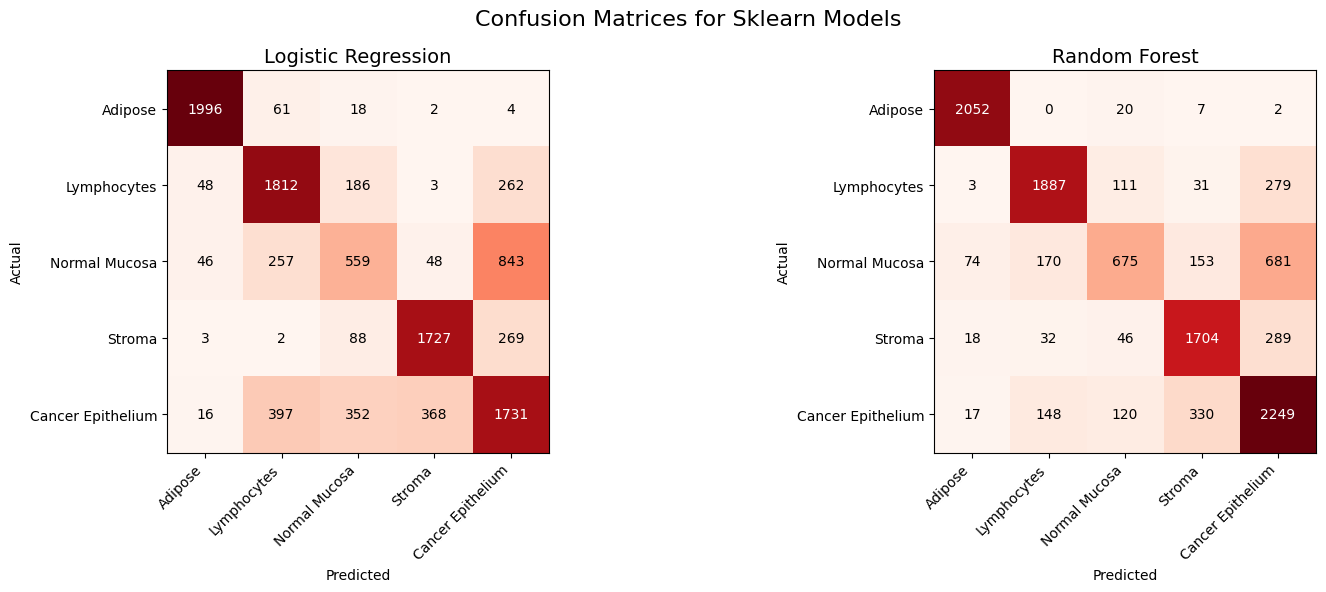

In [22]:
#Confusion Matrices as heatmap


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(axes, 
                              [y_val_pred_lr, y_val_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_val, y_pred)
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.suptitle('Confusion Matrices for Sklearn Models', fontsize=16)
plt.tight_layout()
plt.show()

## F1-Score Comparison
I used F1-score instead of accuracy because it balances precision and recall, 
providing a fairer evaluation metric when classes are imbalanced.

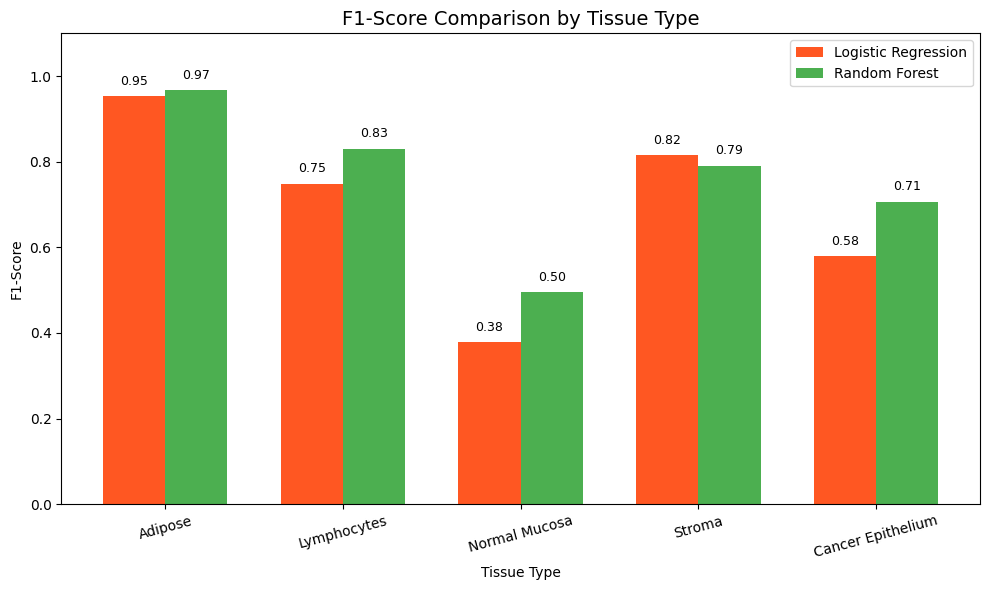

In [23]:
# F1-Score Comparison: Logistic Regression vs Random Forest

fig, ax = plt.subplots(figsize=(10, 6))

lr_report = classification_report(y_val, y_val_pred_lr, output_dict=True)
rf_report = classification_report(y_val, y_val_pred_rf, output_dict=True)

lr_f1 = [lr_report[str(i)]['f1-score'] for i in range(5)]
rf_f1 = [rf_report[str(i)]['f1-score'] for i in range(5)]

x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, lr_f1, width, label='Logistic Regression', color='#FF5722')
bars2 = ax.bar(x + width/2, rf_f1, width, label='Random Forest', color='#4CAF50')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Tissue Type')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison by Tissue Type', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Data format for pytorch

The template converts images to grayscale and uses a single input channel. I instead retain all 3 RGB channels to preserve colour information. PyTorch expects tensors in channel-first format (batch, channels, height, width), so I permute dimensions from NumPy's (batch, height, width, channels).

I split the original training data into train/validation sets using the same stratified split, then wrap everything in DataLoaders for efficient batched training.

In [24]:
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    train_data, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

#Normalise my data set
X_train_cnn = X_train_cnn / 255.0
X_val_cnn = X_val_cnn / 255.0
X_test_cnn = test_data / 255.0

#Pytorch are stored in order of (batch, channel, height, width, hence i need to permute)
X_train_tensor = torch.tensor(X_train_cnn).float().permute(0, 3, 1, 2)
X_val_tensor = torch.tensor(X_val_cnn).float().permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test_cnn).float().permute(0, 3, 1, 2)

#to make sure label remains interger for CrossEntropy loss
y_train_tensor = torch.tensor(y_train_cnn).long()
y_val_tensor = torch.tensor(y_val_cnn).long()
y_test_tensor = torch.tensor(test_labels).long()

# pair image with label for batching 
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# feed CNN in batches and shuffle batches for different epochs
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## CNN Architecture

The template CNN uses 1 input channel (grayscale), 2 convolutional layers, and outputs 9 classes. I on the other hand redesign it with:
- **3 input channels** (RGB) to preserve colour information
- **3 convolutional blocks** (32→64→128 filters) for progressive feature learning
- **BatchNorm** after each convolution for training stability
- **Dropout (0.25)** for regularisation
- **5 output classes** to match the dataset

In [25]:
print(f'Training tensor shape: {X_train_tensor.shape}')
print(f'Validation tensor shape: {X_val_tensor.shape}')
print(f'Test tensor shape: {X_test_tensor.shape}')
print(f'Batch size: {batch_size}')
print(f'Training batches per epoch: {len(train_loader)}')

Training tensor shape: torch.Size([44392, 3, 28, 28])
Validation tensor shape: torch.Size([11098, 3, 28, 28])
Test tensor shape: torch.Size([4367, 3, 28, 28])
Batch size: 64
Training batches per epoch: 694


In [26]:
# CNN Architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(self.dropout(x)))
        x = self.fc2(self.dropout(x))
        return x

model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=5, bias=True)
)


## Hyperparameter Selection and Training

An initial experiment with lr=0.001 produced unstable validation loss. I reduced to lr=0.0001 with a StepLR scheduler (halving every 5 epochs), which produced stable convergence over 20 epochs.

In [27]:
# Train the CNN
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Scheduler: reduces learning rate by half every 5 epochs to help model capture smaller details after initial 
# epochs which learn the bigger differences, to avoid overshooting.
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 20

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = correct / total * 100
    val_accuracies.append(val_accuracy)
    
    scheduler.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f}  '
          f'Val Loss: {val_loss:.4f}  '
          f'Val Accuracy: {val_accuracy:.2f}%  '
          f'LR: {scheduler.get_last_lr()[0]:.6f}')

print('\nTraining complete!')

Epoch [1/20] Train Loss: 0.4431  Val Loss: 0.2593  Val Accuracy: 90.36%  LR: 0.000100
Epoch [2/20] Train Loss: 0.2474  Val Loss: 0.2016  Val Accuracy: 92.75%  LR: 0.000100
Epoch [3/20] Train Loss: 0.1941  Val Loss: 0.1613  Val Accuracy: 94.10%  LR: 0.000100
Epoch [4/20] Train Loss: 0.1630  Val Loss: 0.2045  Val Accuracy: 92.40%  LR: 0.000100
Epoch [5/20] Train Loss: 0.1418  Val Loss: 0.1377  Val Accuracy: 94.86%  LR: 0.000050
Epoch [6/20] Train Loss: 0.1142  Val Loss: 0.1053  Val Accuracy: 96.30%  LR: 0.000050
Epoch [7/20] Train Loss: 0.1043  Val Loss: 0.1109  Val Accuracy: 96.09%  LR: 0.000050
Epoch [8/20] Train Loss: 0.0987  Val Loss: 0.1046  Val Accuracy: 96.28%  LR: 0.000050
Epoch [9/20] Train Loss: 0.0917  Val Loss: 0.1075  Val Accuracy: 96.19%  LR: 0.000050
Epoch [10/20] Train Loss: 0.0856  Val Loss: 0.1082  Val Accuracy: 96.17%  LR: 0.000025
Epoch [11/20] Train Loss: 0.0728  Val Loss: 0.0894  Val Accuracy: 96.74%  LR: 0.000025
Epoch [12/20] Train Loss: 0.0712  Val Loss: 0.0858  

## CNN Validation Evaluation
Evaluating the trained CNN on the validation set to generate a full classification report and compare per-class performance against the sklearn baselines.

In [28]:
#Evaluate the CNN on validation set

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays for sklearn metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print('CNN Results (Validation Set):')
print(f'Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

CNN Results (Validation Set):
Accuracy: 97.13%

Classification Report:
                   precision    recall  f1-score   support

          Adipose       1.00      0.99      1.00      2081
      Lymphocytes       0.99      0.99      0.99      2311
    Normal Mucosa       0.94      0.96      0.95      1753
           Stroma       0.97      0.98      0.97      2089
Cancer Epithelium       0.96      0.95      0.95      2864

         accuracy                           0.97     11098
        macro avg       0.97      0.97      0.97     11098
     weighted avg       0.97      0.97      0.97     11098



Visualising the CNN confusion matrix to inspect where the model still makes errors on the validation set.

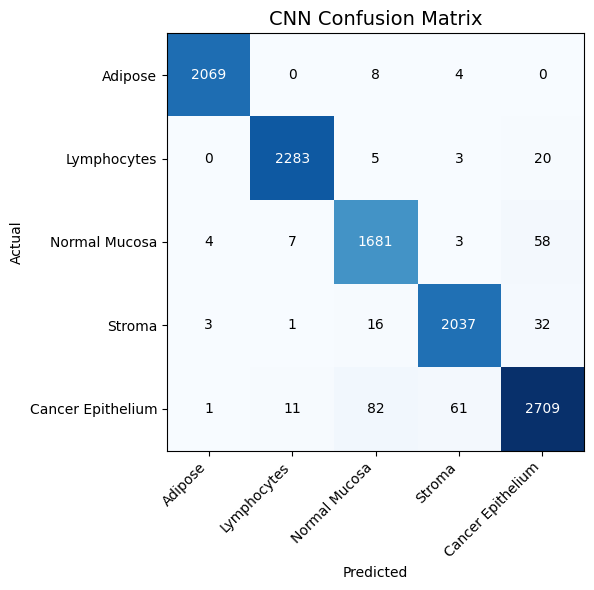

In [29]:
# Confusion Matrix for CNN

fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(all_labels, all_preds)
im = ax.imshow(cm, cmap='Blues')
ax.set_title('CNN Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## Learning Curves
Plotting training and validation loss alongside accuracy over epochs provides evidence that the model trained correctly and did not overfit.

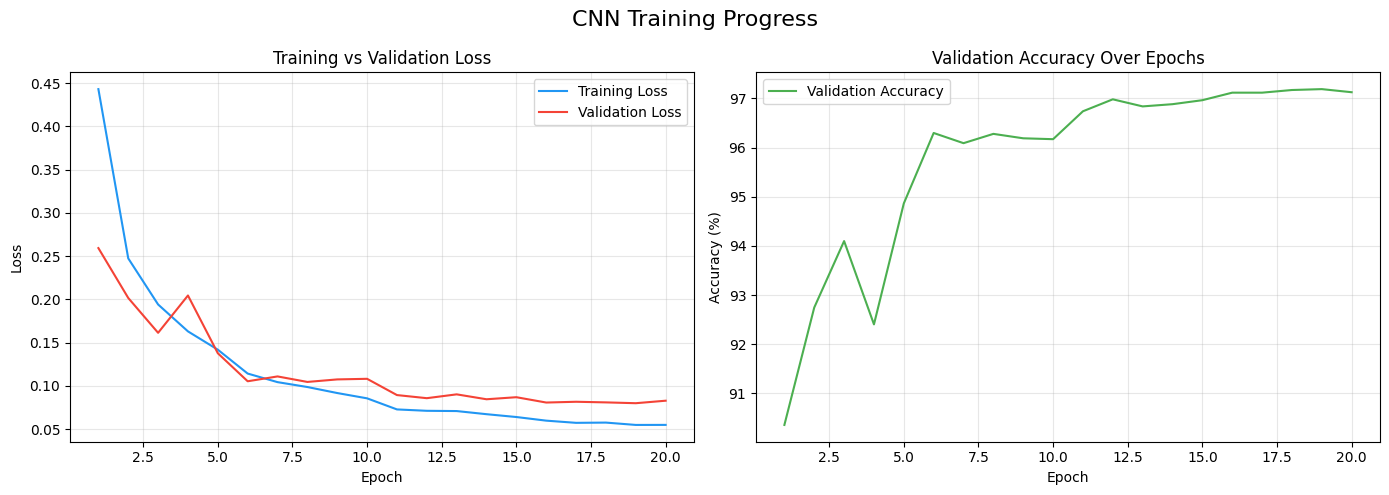

In [30]:
# Learning Curves (to monitor model training properly)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, num_epochs+1), train_losses, label='Training Loss', color='#2196F3')
axes[0].plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='#F44336')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy', color='#4CAF50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

A smooth decrease in both losses proves the model trained well without overfitting.
Model training follows a progressive training, hence it can be trusted not to overfit




## Final Test Set Evaluation
All models are now evaluated on the held-out test set, which comes from a different spatial location in the tissue. This is the true measure of generalisation.

In [31]:
#Evaluating sklearn models on the FINAL TEST SET, 
# kept it till the end so i can view the model performance on the test data cell by cell for CNN, Logistic 
# and additonal random forest model that i have developed

# Logistic Regression on test set
y_test_pred_lr = lr.predict(X_test_flat)

print('LOGISTIC REGRESSION — Final Test Results')
print(f'Accuracy: {accuracy_score(test_labels, y_test_pred_lr)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(test_labels, y_test_pred_lr, target_names=class_names))

# Random Forest on test set
y_test_pred_rf = rf.predict(X_test_flat)

print('RANDOM FOREST — Final Test Results')
print(f'Accuracy: {accuracy_score(test_labels, y_test_pred_rf)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(test_labels, y_test_pred_rf, target_names=class_names))

LOGISTIC REGRESSION — Final Test Results
Accuracy: 67.28%

Classification Report:
                   precision    recall  f1-score   support

          Adipose       0.90      0.98      0.94      1338
      Lymphocytes       0.47      0.51      0.49       634
    Normal Mucosa       0.50      0.27      0.35       741
           Stroma       0.89      0.63      0.74       421
Cancer Epithelium       0.55      0.68      0.61      1233

         accuracy                           0.67      4367
        macro avg       0.66      0.61      0.63      4367
     weighted avg       0.67      0.67      0.66      4367

RANDOM FOREST — Final Test Results
Accuracy: 67.67%

Classification Report:
                   precision    recall  f1-score   support

          Adipose       0.90      0.91      0.90      1338
      Lymphocytes       0.67      0.32      0.44       634
    Normal Mucosa       0.48      0.39      0.43       741
           Stroma       0.83      0.46      0.59       421
Cancer Epith

Evaluating the CNN on the same test set for a direct comparison with the sklearn baselines.

In [32]:
#Evaluating CNN on the final test set

model.eval()
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

print('CNN — Final Test Results')
print(f'Accuracy: {accuracy_score(all_test_labels, all_test_preds)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(all_test_labels, all_test_preds, target_names=class_names))

CNN — Final Test Results
Accuracy: 93.36%

Classification Report:
                   precision    recall  f1-score   support

          Adipose       1.00      0.99      0.99      1338
      Lymphocytes       0.91      0.96      0.94       634
    Normal Mucosa       0.90      0.86      0.88       741
           Stroma       0.95      0.80      0.87       421
Cancer Epithelium       0.89      0.95      0.92      1233

         accuracy                           0.93      4367
        macro avg       0.93      0.91      0.92      4367
     weighted avg       0.93      0.93      0.93      4367



## possible reason Why Sklearn Models Performed Lower on the Test Set

from the assignment brief, it was mentiond that the test set was derived from a different spartial location (different part of the tissue)
The validation set was drawn from the same pool as the training data via an 80/20 stratified split, meaning both sets share similar imaging conditions, staining intensity, and tissue characteristics. The test set, however, originates from a different spatial location within the tissue, introducing subtle variations in appearance that the models had not encountered during training. Logistic Regression and Random Forest operate on flattened pixel vectors, making them sensitive to surface-level patterns such as exact colour values and pixel positions. These patterns do not transfer well when imaging conditions change, resulting in a drop from 70.51% to 67.28% (Logistic Regression) and 77.19% to 67.67% (Random Forest). The CNN experienced a much smaller drop (97.13% to 93.36%) because convolutional layers learn spatial features  edges, textures, and structural arrangements — that are more robust to variations in staining and tissue location.

## Test Set Confusion Matrices
Comparing all three models side by side on the test set to visually inspect where each model struggles.

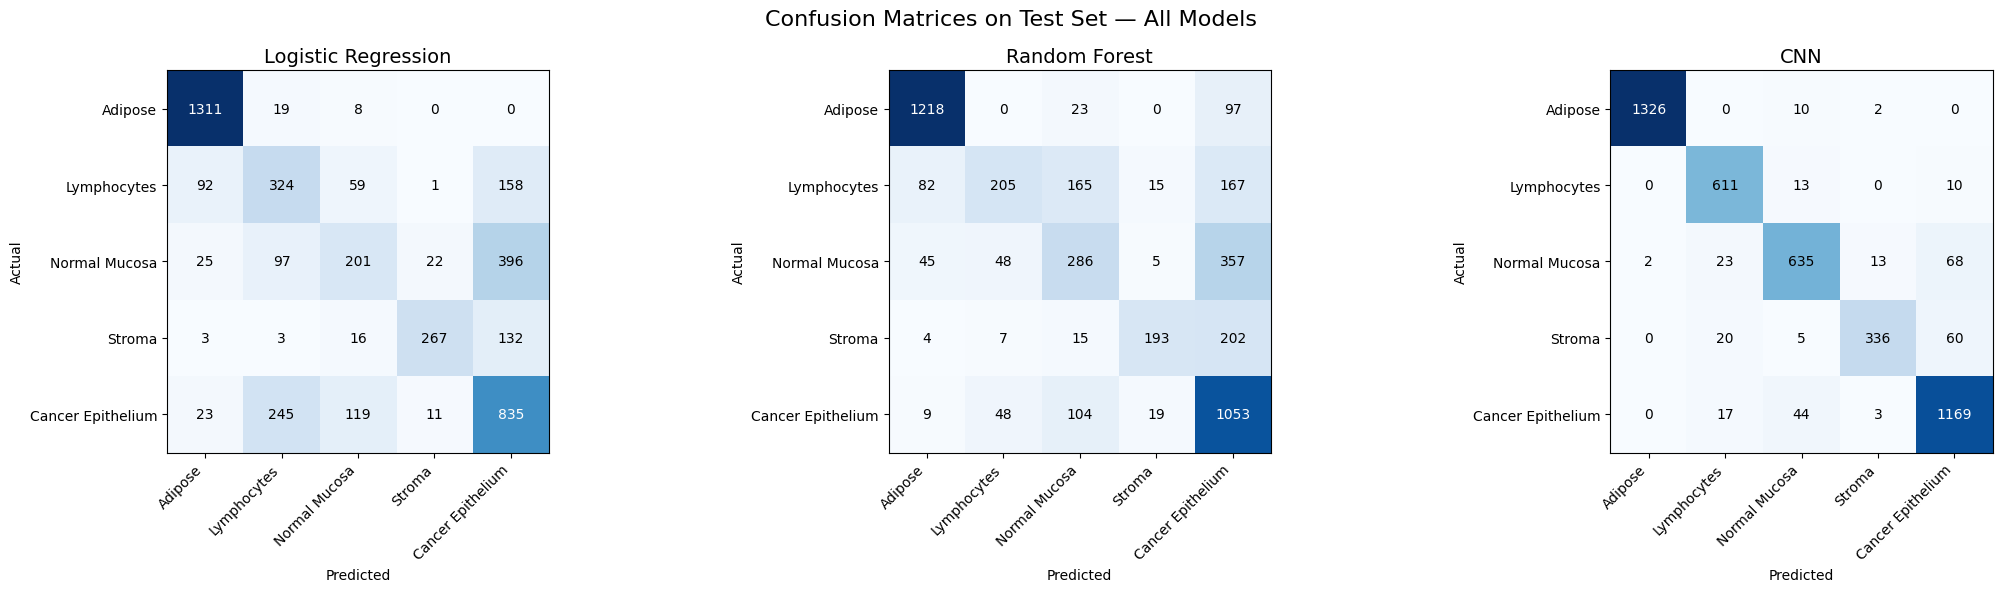

In [33]:
# Confusion Matrices to view test data, for all models

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, y_pred, title in zip(axes,
                              [y_test_pred_lr, y_test_pred_rf, all_test_preds],
                              ['Logistic Regression', 'Random Forest', 'CNN']):
    cm = confusion_matrix(test_labels, y_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.suptitle('Confusion Matrices on Test Set — All Models', fontsize=16)
plt.tight_layout()
plt.show()

The confusion matrices show where each model makes errors on the same test data. The CNN shows far fewer off-diagonal misclassifications compared to the sklearn models.

## Final Model Comparison
A side-by-side F1-score comparison across all tissue types and a summary table for the three classifiers on the test set.

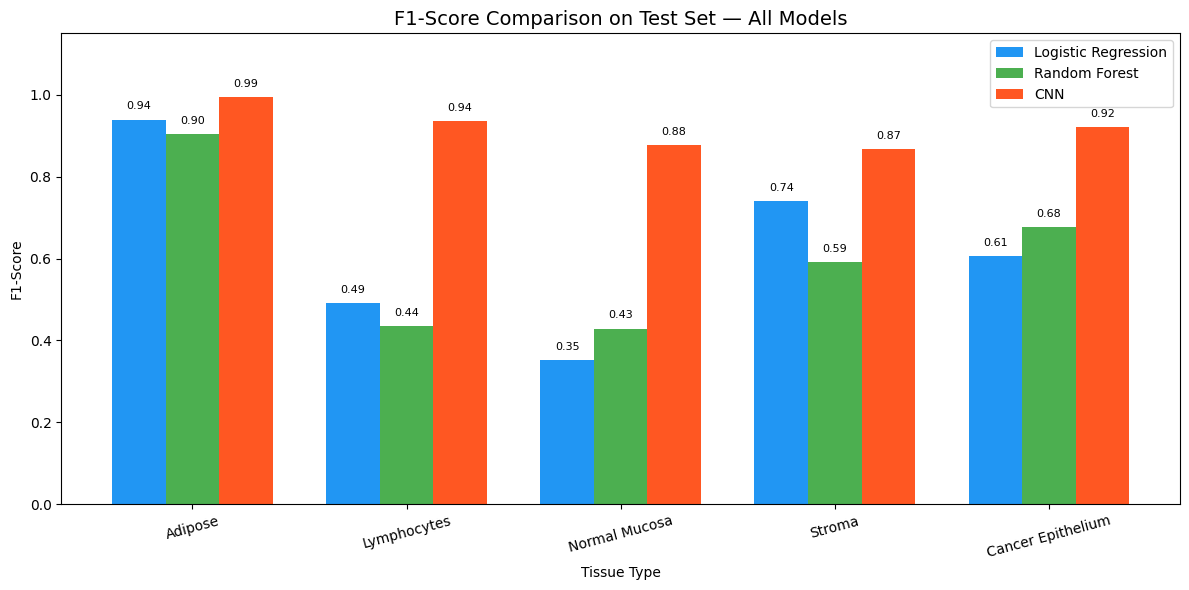


 FINAL SUMMARY — Test Set Results
Model                       Accuracy Macro F1 (avg F1 score from all 5 classes)
Logistic Regression           67.28%      0.63
Random Forest                 67.67%      0.61
CNN                           93.36%      0.92


In [34]:
# Final Model Comparison using histogram and summary table

# Get test F1 scores for each model
lr_test_report = classification_report(test_labels, y_test_pred_lr, output_dict=True)
rf_test_report = classification_report(test_labels, y_test_pred_rf, output_dict=True)
cnn_test_report = classification_report(all_test_labels, all_test_preds, output_dict=True)

lr_test_f1 = [lr_test_report[str(i)]['f1-score'] for i in range(5)]
rf_test_f1 = [rf_test_report[str(i)]['f1-score'] for i in range(5)]
cnn_test_f1 = [cnn_test_report[str(i)]['f1-score'] for i in range(5)]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, lr_test_f1, width, label='Logistic Regression', color='#2196F3')
bars2 = ax.bar(x, rf_test_f1, width, label='Random Forest', color='#4CAF50')
bars3 = ax.bar(x + width, cnn_test_f1, width, label='CNN', color='#FF5722')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Tissue Type')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison on Test Set — All Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

# Print summary table
print('\n FINAL SUMMARY — Test Set Results')
lr_acc = accuracy_score(test_labels, y_test_pred_lr)*100
rf_acc = accuracy_score(test_labels, y_test_pred_rf)*100
cnn_acc = accuracy_score(all_test_labels, all_test_preds)*100
print(f'{"Model":<25} {"Accuracy":>10} {"Macro F1 (avg F1 score from all 5 classes)":>10}')
print(f'{"Logistic Regression":<25} {lr_acc:>9.2f}% {lr_test_report["macro avg"]["f1-score"]:>9.2f}')
print(f'{"Random Forest":<25} {rf_acc:>9.2f}% {rf_test_report["macro avg"]["f1-score"]:>9.2f}')
print(f'{"CNN":<25} {cnn_acc:>9.2f}% {cnn_test_report["macro avg"]["f1-score"]:>9.2f}')